# BlueMesh2D → SWAN Mesh Generation Example (Emodnet)

This notebook walks through a full workflow for generating an unstructured triangular mesh (suitable for SWAN, in `fort.14` format) from Emodnet bathymetry data, using the **BlueMesh2D** toolkit.

Reference: [BlueMesh2D (develop branch)](https://github.com/GeoOcean/BlueMesh2D/tree/develop)

**Workflow overview:**
1. Define the area of interest and a "detail" sub-area that will get a finer mesh resolution.
2. Load Emodnet bathymetry/elevation data for the region.
3. Set the source coordinate reference system and determine a local UTM CRS.
4. Extract coastline and deep-water boundary polygons from the raster data.
5. Build a depth-based mesh-size function (finer near coast/detail area, coarser offshore).
6. Generate the boundary polygon nodes/edges and run Delaunay refinement.
7. Smooth the triangulation.
8. Reproject mesh vertices back to geographic coordinates and interpolate depth values.
9. Identify open/land boundary edges.
10. Export the final mesh to a SWAN-compatible `fort.14` grid file and plot it.

## 1. Imports

Import geometry utilities, projection helpers, mesh-size-function (hfun) builders, boundary identification/export utilities for SWAN (`export_to_grd`, `plot_grd`, `identify_boundary`), and the core BlueMesh2D mesh generation routines (`refine`, `smooth`).

In [2]:
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Point
from shapely.plotting import plot_polygon
import numpy as np

from bluemesh2d.geom_util.proj_util import reproject_geometry, reproject_node, get_local_utm_crs
from bluemesh2d.geom_util.poly_util import polygon_to_node_edge, resample_polygon_hfun
from bluemesh2d.geom_util.getiso import getiso_polygon
from bluemesh2d.geomesh_util.grd_util import export_to_grd, plot_grd
from bluemesh2d.geomesh_util.border_util import identify_boundary
from bluemesh2d.geomesh_util.interpolation_mesh import interpolate_from_xr
from bluemesh2d.geomesh_util.depth_field import depth_field_from_xr
from bluemesh2d.hfun_util.make_depth_hfun import make_depth_hfun
from bluemesh2d.hfun_util.smooth_and_precomput import smooth_precomput_hfun
from bluemesh2d.refine import refine
from bluemesh2d.smooth import smooth

## 2. Area of Interest

Define the center point of the study area and two buffers around it:
- `Detail`: a small (0.3°) radius zone that will receive the finest mesh resolution.
- `Point_of_Interest`: a larger (2°) radius zone defining the overall model domain used to clip the bathymetry data.

In [3]:
Point = Point(-3, 43.4)

Detail = Point.buffer(0.3)
Point_of_Interest = Point.buffer(2)

## 3. Load Bathymetry Data (Emodnet)

Open the Emodnet 2024 bathymetry dataset remotely via OPeNDAP and subset it to the bounding box of `Point_of_Interest`, so only the relevant region is downloaded.

In [4]:
import xarray as xr

# Load Emodnet 2025 data from remote server
Emodnet = xr.open_dataset(
    "https://geoocean.unican.es/thredds/dodsC/aggregatedDatasets/Emodnet2024.nc"
)
# Extract the region of interest
Emodnet_sel = Emodnet.sel(
    lon=slice(Point_of_Interest.bounds[0], Point_of_Interest.bounds[2]),
    lat=slice(Point_of_Interest.bounds[1], Point_of_Interest.bounds[3])
)

Emodnet_sel

<xarray.Dataset> Size: 59MB
Dimensions:    (lat: 3840, lon: 3840)
Coordinates:
  * lat        (lat) float64 31kB 41.4 41.4 41.4 41.4 ... 45.4 45.4 45.4 45.4
  * lon        (lon) float64 31kB -4.999 -4.998 -4.997 ... -1.003 -1.002 -1.001
Data variables:
    elevation  (lat, lon) float32 59MB ...

## 4. Source CRS

Emodnet data is provided in geographic coordinates (WGS84), so the source CRS is set directly to EPSG:4326.

In [5]:
import pyproj

crs = pyproj.CRS.from_epsg(4326)

## 5. Local UTM CRS and Data Cleanup

Fill any NaN values in the elevation grid with a land value (10 m) so gaps in the Emodnet coverage don't break the polygon extraction, then compute an appropriate local UTM CRS for the region. Working in UTM (metric) coordinates is required for accurate distance-based mesh sizing and geometric operations.

In [6]:
lon = Emodnet_sel["lon"]
lat = Emodnet_sel["lat"]
zdat = np.where(np.isnan(Emodnet_sel["elevation"]), 10, Emodnet_sel["elevation"])

utm_crs = get_local_utm_crs(crs, lon, lat)

## 6. Extract Boundary Polygons

Derive polygons from the raster elevation data:
- `polygone_cost`: the coastline/ocean polygon (elevation ≤ 2 m), largest contiguous area kept.
- `polygone_indef`: the "indefinite depth" region (depth > 300 m), used to identify deep-water/offshore areas.

Both are reprojected to the local UTM CRS, and the domain/detail polygons are reprojected as well. The mesh generation polygon (`poly`) is the intersection of the coastline polygon with the overall domain.

In [7]:
# Extract coastline (ocean area)
polygone_cost = max(MultiPolygon(getiso_polygon(lon, lat, zdat, zmax=2.0)).geoms, key=lambda a: a.area)

# Extract indefinite depth region (depth > 300m)
polygone_indef = MultiPolygon(getiso_polygon(lon, lat, -zdat, zmax=300))
polygone_indef = max(polygone_indef.geoms, key=lambda a: a.area)  # Keep only the largest polygon

# Reproject to UTM for metric calculations
polygone_cost_UTM = reproject_geometry(polygone_cost, crs, utm_crs)
polygone_indef_UTM = reproject_geometry(polygone_indef, crs, utm_crs)
domain_UTM = reproject_geometry(Point_of_Interest, crs, utm_crs)
poly_detail_UTM = reproject_geometry(Detail, crs, utm_crs)

poly = polygone_cost_UTM.intersection(domain_UTM)

## 7. Visual Check: Coastline and Detail Area

Plot the Emodnet elevation raster together with the extracted coastline polygon (clipped to the point-of-interest area) and the detail sub-area to visually confirm the extraction looks correct.

(<matplotlib.patches.PathPatch at 0x7261ec1d4bd0>,
 <matplotlib.lines.Line2D at 0x7261ec22cf90>)

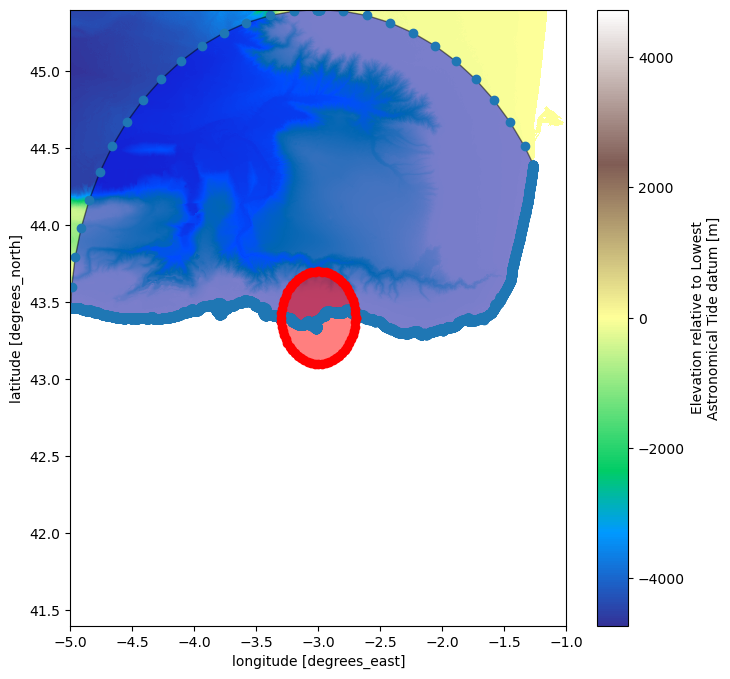

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
Emodnet_sel["elevation"].plot(cmap="terrain", ax=ax)
plot_polygon(polygone_cost.intersection(Point_of_Interest), ax=ax, facecolor="blue", edgecolor="black", alpha=0.5, label='Coastline')
plot_polygon(Detail, ax=ax, color='red', alpha=0.5, label='Detail Area')

## 8. Depth Field and Mesh-Size Function (hfun)

- `depth_field_from_xr` builds a continuous, bilinearly-interpolated depth field from the raw Emodnet grid (avoiding staircase artifacts of the native raster resolution).
- `make_depth_hfun` builds a depth-based mesh-size function: cell size ranges from `hmin` (500 m) in general to `detail_hmin` (50 m) inside the `detail` polygon, up to `hmax` (10000 m) offshore. `slope_ncells`/`slope_step` add extra refinement along the bathymetric slope (e.g. the shelf break); set `slope_ncells=None` to disable this.

Note: the PROJ database version warning shown in the output is a local environment issue (conflicting PROJ installations) and does not affect the results here.

In [10]:
# Depth field (bilinear -> continuous depth, no 10 m staircase)
depth_field = depth_field_from_xr(Emodnet_sel, input_crs=crs, output_crs=utm_crs)

# Depth-based mesh-size function with a finer floor inside the detail area.
# slope_ncells refines the shelf break (bathymetric gradient); set it to
# None to disable the slope refinement.
hfun = make_depth_hfun(
    depth_field,
    hmin=500.0,
    hmax=10000.0,
    detail=poly_detail_UTM,
    detail_hmin=50.0,
    slope_ncells=15,
    slope_step=500.0,
)

ERROR 1: PROJ: internal_proj_create_from_database: /home/etienne/miniconda3/envs/local_env/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


## 9. Smooth and Precompute the hfun

Smooth the mesh-size function so it doesn't change too abruptly between neighboring cells (`max_gradient=0.1` limits the size gradient), then precompute/write it to disk (`hfun_path`) for use by the mesh generator. `plot=True` shows the resulting size-function field.

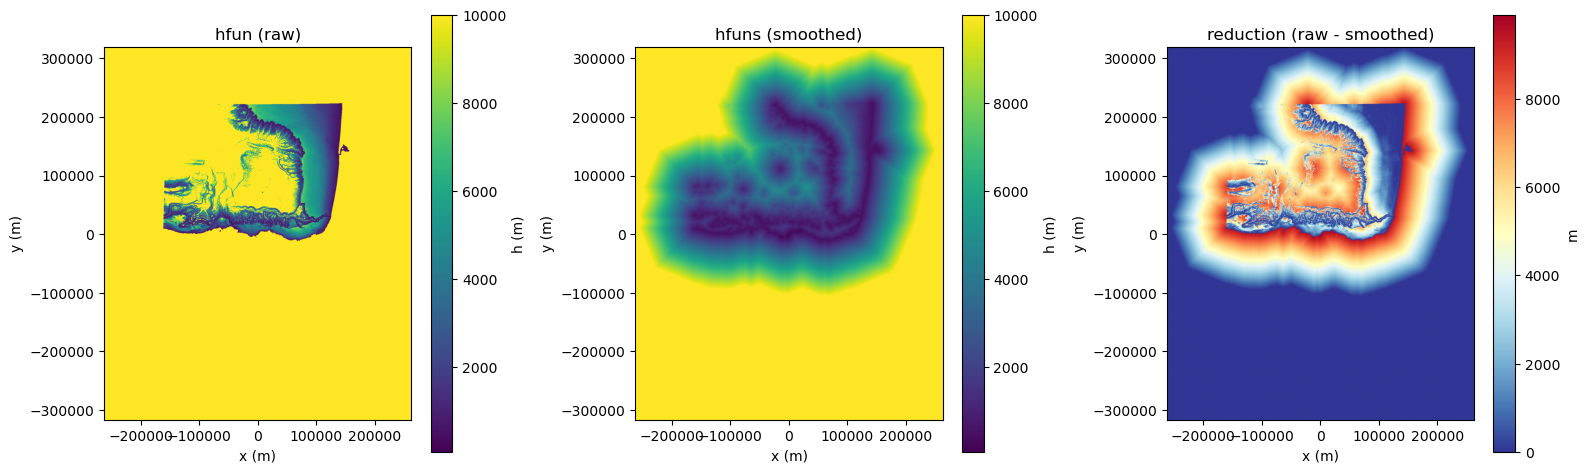

In [11]:
hfun_path = smooth_precomput_hfun(hfun, max_gradient=0.1, plot=True)

## 10. Resample Boundary and Build Node/Edge Topology

Resample the meshing polygon's boundary vertices according to the local mesh size (`hfun_path`), then convert the polygon into the `node`/`edge` arrays required as input to the Delaunay refinement step.

In [12]:
polygone_gen_UTM = resample_polygon_hfun(poly, hfun_path)

node, edge = polygon_to_node_edge(polygone_gen_UTM)

## 11. Delaunay Refinement

Generate the initial constrained Delaunay triangulation and refine it (inserting new vertices) until it satisfies the mesh-size function `hfun_path`. Outputs the mesh vertices (`vert`), edges (`etri`), triangles (`tria`), and triangle region markers (`tnum`).

In [13]:
opts_refine = {"kind": "delaunay"}

vert, etri, tria, tnum = refine(node, edge, [], opts_refine, hfun_path)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          3               1435               1422
         10               1448               2612
         20               1451              15309
         30               1451              58509
         40               1451              73721
         41               1451              73723



## 12. Mesh Smoothing

Apply Laplacian-style smoothing to the triangulation to improve triangle quality (moving vertices, flipping triangles) while still honoring the mesh-size function. Unlike the D-Flow FM workflow, no additional `smood` pass is needed here since SWAN does not require that specific mesh regularity.

In [14]:
vert, etri, tria, tnum = smooth(vert, etri, tria,  tnum, {}, hfun_path)


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0              34922              74849
          4              32324              69769
          8              26270              68571
         12              17276              67879
         16              10517              67625
         20               7618              67555
         24               5763              67497
         28               4855              67441



## 13. Reproject Mesh Nodes to Geographic Coordinates

Convert the mesh vertex coordinates from the local UTM CRS back to the original geographic CRS (lon/lat), so they can be matched against the Emodnet grid for depth interpolation.

In [15]:
vert_geo = reproject_node(vert, utm_crs, crs)

## 14. Interpolate Depth at Mesh Nodes

Interpolate the Emodnet elevation/depth values onto each mesh vertex position, giving the bathymetry (`z`) that will be assigned to the final mesh.

In [16]:
z = interpolate_from_xr(Emodnet_sel, vert_geo)

## 15. Identify Boundary Edges

Classify the mesh's outer boundary edges as open (sea) or land boundaries, based on depth (`zlim=8`): edges shallower than the limit are treated as land, and the rest as open ocean boundaries. This is required by SWAN's `fort.14` boundary format.

In [26]:
Boundary = identify_boundary(vert_geo, tria, z, zlim=8)

## 16. Export to SWAN `fort.14`

Write the triangulated mesh (nodes with lon/lat/depth, triangle connectivity, and boundary tags) to the ADCIRC-style `fort.14` grid file used by SWAN.

In [27]:
export_file = "fort.14"

export_to_grd(
    export_file,
    vert=vert_geo,
    tria=tria,
    z=z,
    crs=crs,
    edge_tag=Boundary["edge_tag"],
    edge_open=Boundary["edge_open"],
    edge_land=Boundary["edge_land"],
)

## 17. Plot the Exported Grid

Load and plot the exported `fort.14` grid, highlighting the identified open/land boundaries, as a final sanity check.

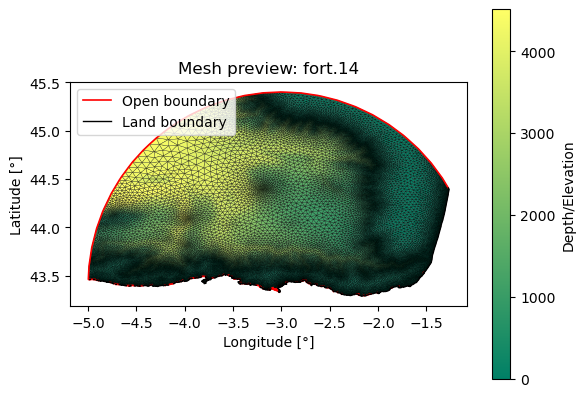

In [28]:
plot_grd(export_file, show_boundaries=True)